# DCT Laboratory — Volume I, Chapter 2
## Enterprise Systems and Transformation
**Seed `26102`** · Companion to the chapter and AXIOM Module **AXIOM-02**

The chapter's four formal moves, made computational: the enterprise as an **open
system** $S = (\mathcal{X}, \mathcal{U}, \mathcal{W}, \mathcal{Y}, f, g, \mathbf{x}_0)$,
the **boundary** as a modeling decision, **feedback** ($u_k = \varphi(x_k)$) against the
environment's pull, and transformation as a designed steering process. The
deterministic core is mirrored in `DCT_V1_Ch02_Lab.xlsx`; validation at the end.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26102
DT, N = 1/12, 60
A_PULL, B_GAIN, K_FB = 0.8, 0.5, 1.6
X0, X_ENV, X_STAR = 68.0, 60.0, 75.0

def simulate(feedback, x0=X0, n=N):
    x = np.empty(n+1); x[0] = x0
    for k in range(n):
        u = K_FB*(X_STAR - x[k]) if feedback else 0.0
        x[k+1] = x[k] + DT*(A_PULL*(X_ENV - x[k]) + B_GAIN*u)
    return x

def mc_fan(n_paths=200, sigma=0.9):
    rng = np.random.default_rng(SEED)
    out = np.empty((n_paths, N+1))
    for p in range(n_paths):
        x = X0
        out[p,0] = x
        for k in range(N):
            u = K_FB*(X_STAR - x)
            x = x + DT*(A_PULL*(X_ENV - x) + B_GAIN*u) + sigma*np.sqrt(DT)*rng.standard_normal()
            out[p,k+1] = x
    return out

# Boundary panel: 4 subsystem efficiency states; two boundary choices = weights
SUBS = np.array([72.0, 61.0, 58.0, 80.0])   # Industrial, Digital, Shared-services, Ventures
W_B1 = np.array([0.45, 0.30, 0.25, 0.00])   # ventures outside the boundary
W_B2 = np.array([0.40, 0.27, 0.22, 0.11])   # ventures inside

def reference_values():
    op, cl = simulate(False), simulate(True)
    return {
        "open_loop_t5.0":  round(op[-1], 4),
        "closed_loop_t5.0":round(cl[-1], 4),
        "feedback_gap_t5.0": round(cl[-1]-op[-1], 4),
        "closed_loop_t1.0": round(cl[12], 4),
        "aggregate_B1": round(float(W_B1 @ SUBS), 4),
        "aggregate_B2": round(float(W_B2 @ SUBS), 4),
        "boundary_shift": round(float((W_B2-W_B1) @ SUBS), 4),
    }
if __name__ == "__main__":
    [print(f"{k:22s} {v}") for k,v in reference_values().items()]

open_loop_t5.0         60.1274
closed_loop_t5.0       67.5001
feedback_gap_t5.0      7.3727
closed_loop_t1.0       67.5898
aggregate_B1           65.2
aggregate_B2           66.83
boundary_shift         1.63


## Panel 1 — Open loop vs. feedback
Operational efficiency $x_5$ with the environment pulling toward $x_e = 60$.
Without control the enterprise drifts to its environment; the feedback law
$u_k = K(x^* - x_k)$ (Definition: enterprise feedback) holds it near target.
Feedback acts on **inputs**; adaptation (not simulated here) acts on the **rule**.

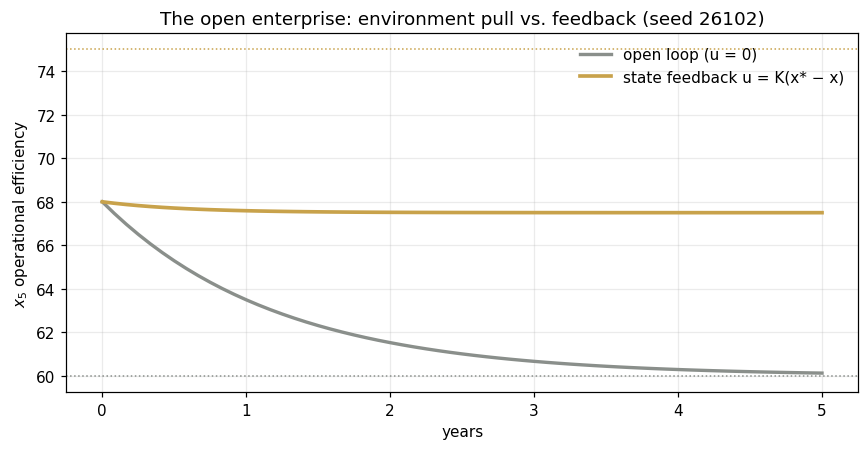

gap at t=5: 7.3727


In [2]:
op, cl = simulate(False), simulate(True)
t = np.arange(N+1)/12
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(t, op, color="#8A8F8B", lw=2.2, label="open loop (u = 0)")
ax.plot(t, cl, color="#C8A24B", lw=2.4, label="state feedback u = K(x* − x)")
ax.axhline(X_ENV, ls=":", c="#8A8F8B", lw=1); ax.axhline(X_STAR, ls=":", c="#C8A24B", lw=1)
ax.set(xlabel="years", ylabel="$x_5$ operational efficiency",
       title="The open enterprise: environment pull vs. feedback (seed 26102)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print("gap at t=5:", round(cl[-1]-op[-1],4))

## Panel 2 — The seeded fan under disturbance
The environment channel $\mathcal{W}$ made stochastic: 200 disturbed closed-loop
paths, seed `26102`. Feedback doesn't remove uncertainty — it shapes where the
distribution settles.

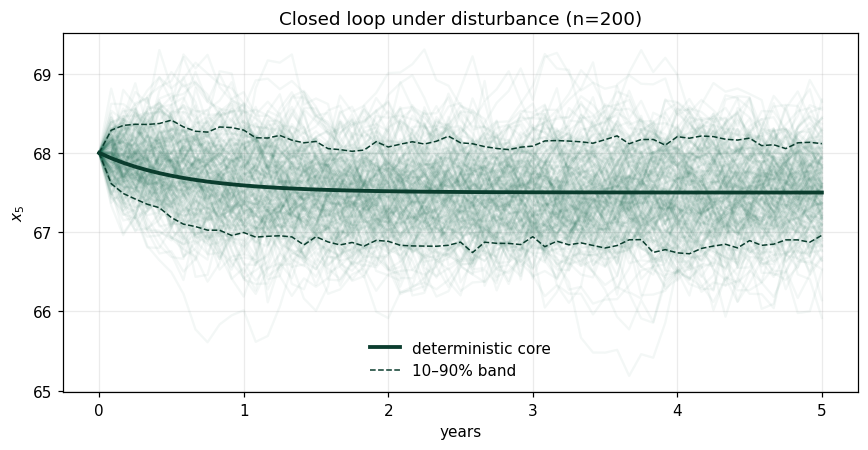

In [3]:
paths = mc_fan()
fig, ax = plt.subplots(figsize=(8,4.2))
ax.plot(t, paths.T, color="#1B6B52", alpha=.05)
ax.plot(t, simulate(True), color="#0B3D2E", lw=2.5, label="deterministic core")
q10,q90 = np.quantile(paths,[.1,.9],axis=0)
ax.plot(t,q10,"--",c="#0B3D2E",lw=1); ax.plot(t,q90,"--",c="#0B3D2E",lw=1,label="10–90% band")
ax.set(xlabel="years", ylabel="$x_5$", title="Closed loop under disturbance (n=200)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

## Panel 3 — The boundary is a modeling decision
Four subsystems; two defensible boundaries. $B_1$ leaves Ventures outside; $B_2$
brings it in. The **same enterprise** reports a different aggregate state under
each — nothing is wrong, and the difference is exactly what the Boundary
Consistency Theorem disciplines.

In [4]:
names=["Industrial","Digital","Shared services","Ventures"]
for nm,s,w1,w2 in zip(names,SUBS,W_B1,W_B2):
    print(f"{nm:16s} state={s:5.1f}   weight B1={w1:.2f}  B2={w2:.2f}")
print("\naggregate under B1:", round(float(W_B1@SUBS),4))
print("aggregate under B2:", round(float(W_B2@SUBS),4))
print("boundary shift    :", round(float((W_B2-W_B1)@SUBS),4))

Industrial       state= 72.0   weight B1=0.45  B2=0.40
Digital          state= 61.0   weight B1=0.30  B2=0.27
Shared services  state= 58.0   weight B1=0.25  B2=0.22
Ventures         state= 80.0   weight B1=0.00  B2=0.11

aggregate under B1: 65.2
aggregate under B2: 66.83
boundary shift    : 1.63


## Validation — agrees with `DCT_V1_Ch02_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"open_loop_t5.0":60.1274,"closed_loop_t5.0":67.5001,"feedback_gap_t5.0":7.3727,
 "closed_loop_t1.0":67.5898,"aggregate_B1":65.2,"aggregate_B2":66.83,"boundary_shift":1.63}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:22s} {ref[k]}")
print("\nAll checkpoints agree — seed 26102.")

PASS  open_loop_t5.0         60.1274
PASS  closed_loop_t5.0       67.5001
PASS  feedback_gap_t5.0      7.3727
PASS  closed_loop_t1.0       67.5898
PASS  aggregate_B1           65.2
PASS  aggregate_B2           66.83
PASS  boundary_shift         1.63

All checkpoints agree — seed 26102.


**Next**: Exercises 2.9–2.12 (Part C) extend this laboratory; AXIOM-02's boundary designer makes Panel 3 draggable. Solutions: IM Ch. 2.